#### Feature Scaling

##### (1)Standardisation
###### Xnew = (Xi -Xmean)/Standard deviation
##### (2)Normalization(Min-Max Scaling)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
dataset = pd.read_csv("loan.csv")
dataset.head(3)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP00001,Male,Yes,2,Graduate,Yes,16337,7648,574.0,360.0,0.0,Semiurban,N
1,LP00002,NaN,No,0,Graduate,NaN,24986,9550,261.0,360.0,1.0,Rural,Y
2,LP00003,Female,Yes,0,Graduate,No,8812,5115,74.0,NaN,1.0,Semiurban,Y


In [3]:
dataset.isnull().sum()

Loan_ID               0
Gender                9
Married              10
Dependents           10
Education             0
Self_Employed        17
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      7
Credit_History       10
Property_Area         0
Loan_Status           0
dtype: int64

In [ ]:
dataset["ApplicantIncome"].fillna(dataset["ApplicantIncome"].mean(),inplace= True)

C:\Users\sures\AppData\Local\Temp\ipykernel_16164\1426759662.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset["new_appli_income"]=dataset["ApplicantIncome"].fillna(dataset["ApplicantIncome"].mean(),inplace= True)


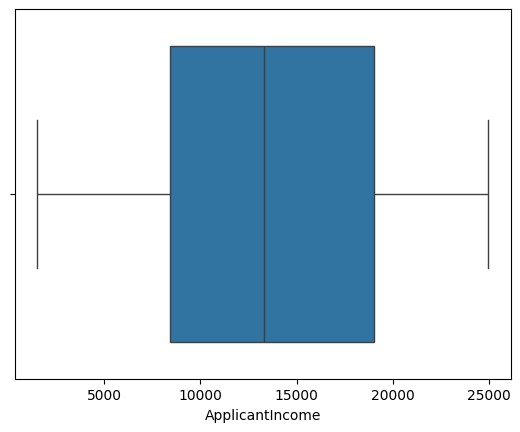

In [10]:
sns.boxplot(x=dataset["ApplicantIncome"],data=dataset)
plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
ss= StandardScaler()
ss.fit(dataset[["ApplicantIncome"]])

,copy,True
,with_mean,True
,with_std,True


In [13]:
ss.transform(dataset[["ApplicantIncome"]])

array([[ 0.43532608],
       [ 1.74226083],
       [-0.70176307],
       [-1.00277059],
       [ 0.1903797 ],
       [ 1.59568589],
       [-1.3867365 ],
       [ 0.80871442],
       [-1.56776412],
       [ 1.17137408],
       [ 0.10893238],
       [-0.94338507],
       [ 1.73077661],
       [ 0.70762304],
       [-1.08074241],
       [ 0.94682731],
       [-0.27503353],
       [-1.80530619],
       [ 1.10292207],
       [-1.03238779],
       [-1.65329135],
       [-1.4752859 ],
       [-0.53509073],
       [ 0.24084984],
       [ 0.38621592],
       [-1.1783583 ],
       [ 1.26219011],
       [-0.75344207],
       [-0.75827753],
       [ 1.39199204],
       [ 0.27439586],
       [ 1.27352322],
       [ 0.91585013],
       [-0.24360303],
       [-0.70871404],
       [-0.49172268],
       [-1.74864062],
       [-1.74561846],
       [-0.5713567 ],
       [ 0.48383181],
       [ 0.12192769],
       [ 0.97130684],
       [-0.31673939],
       [-0.9016792 ],
       [ 0.47597418],
       [ 0

In [19]:
# putting into dataframe
dataset["ApplicantIncome_SS"]= pd.DataFrame(ss.transform(dataset[["ApplicantIncome"]]))
dataset

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,new_appli_income,ApplicantIncome_SS
0,LP00001,Male,Yes,2,Graduate,Yes,16337,7648,574.0,360.000000,0.0,Semiurban,N,None,0.435326
1,LP00002,NaN,No,0,Graduate,NaN,24986,9550,261.0,360.000000,1.0,Rural,Y,None,1.742261
2,LP00003,Female,Yes,0,Graduate,No,8812,5115,74.0,267.096774,1.0,Semiurban,Y,None,-0.701763
3,LP00004,Female,No,3+,Graduate,No,6820,4637,629.0,180.000000,1.0,Urban,Y,None,-1.002771
4,LP00005,Male,NaN,2,Not Graduate,No,14716,4854,443.0,360.000000,0.0,Semiurban,N,None,0.190380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,LP00096,Female,Yes,2,Not Graduate,No,8441,6229,285.0,360.000000,0.0,Rural,N,None,-0.757824
96,LP00097,Female,No,3+,Not Graduate,No,24886,7641,383.0,180.000000,1.0,Semiurban,Y,None,1.727150
97,LP00098,Male,No,0,Graduate,Yes,11709,125,425.0,360.000000,NaN,Semiurban,Y,None,-0.264003
98,LP00099,Male,No,2,Not Graduate,NaN,19215,4632,508.0,180.000000,0.0,Semiurban,Y,None,0.870215


In [20]:
dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,ApplicantIncome_SS
count,100.000000,100.000000,100.00000,100.000000,90.000000,1.000000e+02
mean,13456.110000,4877.790000,389.50000,267.096774,0.711111,-9.325873e-17
std,6651.114018,2629.982188,196.22485,94.778643,0.455785,1.005038e+00
min,1509.000000,55.000000,50.00000,120.000000,0.000000,-1.805306e+00
25%,8423.750000,2823.250000,220.00000,180.000000,0.000000,-7.604308e-01
50%,13321.500000,5125.000000,376.50000,267.096774,1.000000,-2.034067e-02
75%,19024.500000,6895.750000,568.75000,360.000000,1.000000,8.414293e-01
max,24986.000000,9945.000000,699.00000,360.000000,1.000000,1.742261e+00
